In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/My Drive/PASCAL_VOC.zip" -d "/content/PASCAL_VOC"

Streaming output truncated to the last 5000 lines.
  inflating: /content/PASCAL_VOC/labels/2009_004289.txt  
  inflating: /content/PASCAL_VOC/labels/2009_004290.txt  
  inflating: /content/PASCAL_VOC/labels/2009_004291.txt  
  inflating: /content/PASCAL_VOC/labels/2009_004295.txt  
  inflating: /content/PASCAL_VOC/labels/2009_004298.txt  
  inflating: /content/PASCAL_VOC/labels/2009_004300.txt  
  inflating: /content/PASCAL_VOC/labels/2009_004301.txt  
  inflating: /content/PASCAL_VOC/labels/2009_004303.txt  
  inflating: /content/PASCAL_VOC/labels/2009_004307.txt  
  inflating: /content/PASCAL_VOC/labels/2009_004308.txt  
  inflating: /content/PASCAL_VOC/labels/2009_004309.txt  
  inflating: /content/PASCAL_VOC/labels/2009_004312.txt  
  inflating: /content/PASCAL_VOC/labels/2009_004315.txt  
  inflating: /content/PASCAL_VOC/labels/2009_004316.txt  
  inflating: /content/PASCAL_VOC/labels/2009_004317.txt  
  inflating: /content/PASCAL_VOC/labels/2009_004319.txt  
  inflating: /content

In [ ]:
import os
import config
import torch
import torch.optim as optim

from model import YOLOv3
from tqdm import tqdm
from utils import (
    mean_average_precision,
    cells_to_bboxes,
    get_evaluation_bboxes,
    save_checkpoint,
    load_checkpoint,
    check_class_accuracy,
    get_loaders,
    plot_couple_examples
)
from loss import YoloLoss
import warnings
warnings.filterwarnings("ignore")

torch.backends.cudnn.benchmark = True

In [ ]:
model = YOLOv3(num_classes=config.NUM_CLASSES).to(config.DEVICE)
optimizer = optim.Adam(
    model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY
)
loss_fn = YoloLoss()
scaler = torch.cuda.amp.GradScaler()

train_loader, test_loader, train_eval_loader = get_loaders(
    train_csv_path=config.DATASET + "/train.csv", test_csv_path=config.DATASET + "/test.csv"
)

if config.LOAD_MODEL:
    if os.path.exists(config.CHECKPOINT_FILE):  # Check if the file exists
        load_checkpoint(
            config.CHECKPOINT_FILE, model, optimizer, config.LEARNING_RATE
        )
        print(f"Checkpoint {config.CHECKPOINT_FILE} loaded successfully.")
    else:
        print(f"Checkpoint file {config.CHECKPOINT_FILE} not found. Training from scratch.")
else:
    print("Training from scratch, no checkpoint file loading.")

scaled_anchors = (
    torch.tensor(config.ANCHORS)
    * torch.tensor(config.S).unsqueeze(1).unsqueeze(1).repeat(1, 3, 2)
).to(config.DEVICE)


=> Loading checkpoint
Checkpoint checkpoint.pth.tar loaded successfully.


In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
from train import train_fn

In [ ]:
CHECKPOINT_DIR = "/content/drive/MyDrive/yolo_checkpoints"

import os
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [ ]:
class_accuracy = []
no_obj_accuracy = []
obj_accuracy = []

# Training loop
for epoch in range(config.NUM_EPOCHS):
    train_fn(train_loader, model, optimizer, loss_fn, scaler, scaled_anchors)

    # Save checkpoint if specified
    if not config.SAVE_MODEL:
        checkpoint_path = f"{CHECKPOINT_DIR}/checkpoint_epoch.pth.tar"
        save_checkpoint(model, optimizer, filename=checkpoint_path)

    print(f"Currently epoch {epoch}")
    print("On Train Eval loader:")
    print("On Train loader:")
    epoch_class_accuracy, epoch_no_obj_accuracy, epoch_obj_accuracy = check_class_accuracy(
        model, train_loader, threshold=config.CONF_THRESHOLD
    )

    # Store the accuracies in lists
    class_accuracy.append(epoch_class_accuracy)
    no_obj_accuracy.append(epoch_no_obj_accuracy)
    obj_accuracy.append(epoch_obj_accuracy)

    if epoch > 0 and epoch % 3 == 0:
        # Track class accuracy on the test set
        epoch_test_class_accuracy = check_class_accuracy(model, test_loader, threshold=config.CONF_THRESHOLD)
        print(f"Test Class Accuracy at epoch {epoch}: {epoch_test_class_accuracy:.2f}%")
        pred_boxes, true_boxes = get_evaluation_bboxes(
            test_loader,
            model,
            iou_threshold=config.NMS_IOU_THRESH,
            anchors=config.ANCHORS,
            threshold=config.CONF_THRESHOLD,
        )
        mapval = mean_average_precision(
            pred_boxes,
            true_boxes,
            iou_threshold=config.MAP_IOU_THRESH,
            box_format="midpoint",
            num_classes=config.NUM_CLASSES,
        )
        print(f"MAP: {mapval.item()}")

        model.train()

=> Saving checkpoint
Currently epoch 0/20
On Train Eval loader:
On Train loader:
100%|████████████████████████████████████████| 518/518 [6:37]<00:00, 1.33it/s, loss=8.00
Class accuracy is: 88.196173%
No obj accuracy is: 89.572019%
Obj accuracy is: 81.377641%
100%|████████████████████████████████████████| 518/518 [7:59]<00:00, 1.41it/s, loss=8.00
=> Saving checkpoint
=> Saving checkpoint
Currently epoch 1/20
On Train Eval loader:
On Train loader:
100%|████████████████████████████████████████| 518/518 [7:21]<00:00, 1.53it/s, loss=8.59
Class accuracy is: 79.909043%
No obj accuracy is: 86.193031%
Obj accuracy is: 79.132002%
100%|████████████████████████████████████████| 518/518 [7:46]<00:00, 1.33it/s, loss=8.59
=> Saving checkpoint
=> Saving checkpoint
Currently epoch 2/20
On Train Eval loader:
On Train loader:
100%|████████████████████████████████████████| 518/518 [5:50]<00:00, 1.32it/s, loss=5.34
Class accuracy is: 70.227994%
No obj accuracy is: 91.602621%
Obj accuracy is: 78.411849%
100

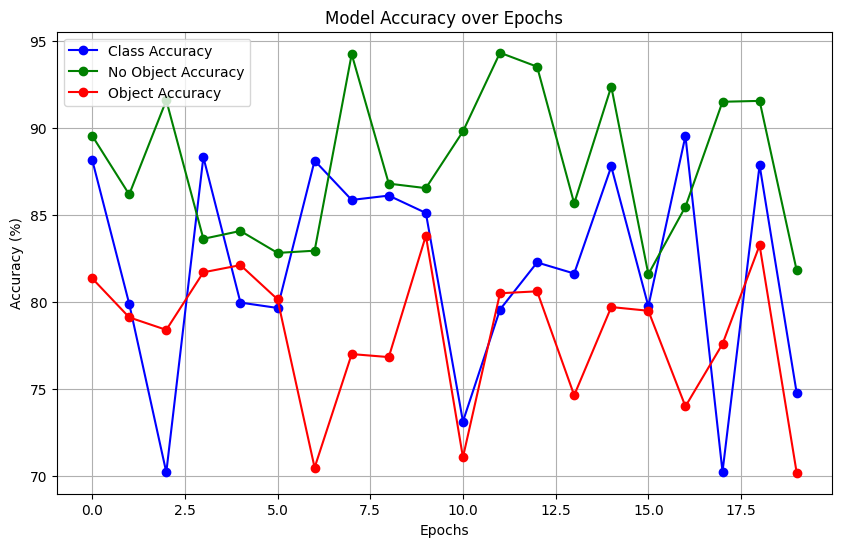

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(len(class_accuracy_list))
plt.figure(figsize=(10, 6))

plt.plot(epochs, class_accuracy, label='Class Accuracy', marker='o', linestyle='-', color='blue')
plt.plot(epochs, no_obj_accuracy, label='No Object Accuracy', marker='o', linestyle='-', color='green')
plt.plot(epochs, obj_accuracy, label='Object Accuracy', marker='o', linestyle='-', color='red')

plt.title('Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()


In [2]:
final_model_path = "trained_model.pt"
torch.save(model.state_dict(), final_model_path)
print(f"Model saved Successfully")

Model saved Successfully
